# Does Foreign Aid Predict Government Health Spending in Sub-Saharan Africa, and Does Corruption Weaken That Effect?

**Stat 248 Final Project — Spring 2026**



## Research Question

Does foreign aid (ODA) received in year T predict increases in government health expenditure at lags T+1 through T+3 across Sub-Saharan African countries, and is that relationship weaker in countries with poorer governance quality?

## Motivation

A central debate in development economics is whether foreign aid actually changes government spending behavior, or whether governments substitute aid for domestic revenue and redirect spending elsewhere. Establishing causality between aid, corruption, and health outcomes is difficult because many unobserved confounding factors may influence these relationships simultaneously. Therefore, this analysis asks a more manageable question: **does aid money reach the health sector at all?**

Government health expenditure as a share of GDP is a direct measure of health system investment. If aid is being used as intended, we would expect ODA inflows to predict higher health spending in subsequent years. Governance quality moderates this relationship: in countries with weaker institutional controls, aid is more likely to be diverted or  reallocated before it reaches health budgets.

**Why is this a time series problem?**
This is a time series problem because both ODA and health expenditure are strongly autocorrelated over time, and the mechanism is explicitly lagged — aid allocated in year T must pass through procurement and budget cycles before it appears as health spending, a process that plausibly takes 1–3 years. Treating country-year observations as independent would ignore this lag structure and produce invalid standard errors due to within-country residual correlation.

**Governance indicator:** The World Bank Control of Corruption score (CC.EST) captures broad institutional quality, not corruption alone. A weak governance–aid relationship could reflect diversion to private pockets, but also legitimate reallocation to non-health priorities. This is also listed as a lmitation on the presentation slide, but including it here would give context as such I have added it here.

**ODA measure:** The indicator used (`DT.ODA.ALLD.CD`) is total net ODA (Official Development Assistance), which includes health, infrastructure, education, and budget support. Because of this, the relationship between aid and health spending may appear weaker than if I had used health-specific aid only.

In [1]:

import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, ccf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.formula.api as smf

## 1. Data

All data comes from the World Bank Open Data portal, accessed via the `wbgapi` Python package. The dataset covers 48 Sub-Saharan African countries from 2000 to 2022 (23 annual time points per country, ~1,100 country-year observations).

Three indicators are used:
- **ODA** (`DT.ODA.ALLD.CD`): Total net official development assistance received, in current USD. Primary predictor.
- **Health expenditure** (`SH.XPD.CHEX.GD.ZS`): Current health expenditure as % of GDP. Primary outcome.
- **Governance** (`CC.EST`): World Bank Control of Corruption estimate, ranging from −2.5 (weakest) to +2.5 (strongest). Moderating variable.
- **Population** (`SP.POP.TOTL`): Used to compute ODA per capita.

Corruption data is loaded from a separately downloaded World Bank CSV (`corruption.csv`). (I had  hard time fetching the data, so i downloaded it locally and used it)

In [4]:
# import data from the World Bank API

indicators = {
    "DT.ODA.ALLD.CD": "oda",
    "SH.XPD.CHEX.GD.ZS": "health_exp_gdp",
    "SP.POP.TOTL": "population"
}

years = range(2000, 2023)

# Sub-Saharan Africa country codes
ssa_codes = [
    e["id"] for e in wb.economy.list()
    if e.get("region") == "SSF" and e.get("incomeLevel") != "NA"
]

raw = wb.data.DataFrame(
    indicators.keys(),
    economy=ssa_codes,
    time=years,
    labels=True
)

raw.head()

,,Country,Series,YR2000,YR2001,YR2002,YR2003,YR2004,YR2005,YR2006,YR2007,...,YR2013,YR2014,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022
economy,series,,,,,,,,,,,,,,,,,,,,,
ZWE,DT.ODA.ALLD.CD,Zimbabwe,Net official development assistance and offici...,1.756400e+08,1.602117e+08,1.991267e+08,1.869248e+08,1.872982e+08,3.729382e+08,2.782400e+08,4.774577e+08,...,8.275392e+08,7.605741e+08,7.882866e+08,6.542527e+08,7.258257e+08,7.945562e+08,8.454113e+08,9.863097e+08,9.873951e+08,7.880725e+08
ZMB,DT.ODA.ALLD.CD,Zambia,Net official development assistance and offici...,7.946500e+08,5.708400e+08,8.107294e+08,7.704494e+08,1.128445e+09,1.169046e+09,1.470271e+09,1.022490e+09,...,1.145246e+09,9.977277e+08,7.976810e+08,9.664647e+08,1.040495e+09,1.000315e+09,9.486743e+08,1.017031e+09,1.089043e+09,1.823696e+09
ZAF,DT.ODA.ALLD.CD,South Africa,Net official development assistance and offici...,4.900148e+08,4.288793e+08,5.069619e+08,6.421490e+08,6.316148e+08,6.812349e+08,7.232406e+08,7.951245e+08,...,1.295342e+09,1.077397e+09,1.420274e+09,1.180280e+09,1.014809e+09,9.209711e+08,9.659032e+08,1.204524e+09,1.042873e+09,1.029896e+09
UGA,DT.ODA.ALLD.CD,Uganda,Net official development assistance and offici...,8.559316e+08,8.289434e+08,7.329753e+08,1.003709e+09,1.222242e+09,1.195335e+09,1.589232e+09,1.738146e+09,...,1.697090e+09,1.633681e+09,1.638164e+09,1.762598e+09,2.011815e+09,1.945595e+09,2.030926e+09,3.087861e+09,2.565441e+09,2.156963e+09
TZA,DT.ODA.ALLD.CD,Tanzania,Net official development assistance and offici...,1.064254e+09,1.274898e+09,1.260430e+09,1.725765e+09,1.774205e+09,1.492452e+09,1.887650e+09,2.823809e+09,...,3.433236e+09,2.650519e+09,2.584706e+09,2.317893e+09,2.585599e+09,2.455195e+09,2.126977e+09,2.278316e+09,2.619770e+09,2.645266e+09


In [5]:
# Reshape from wide to long
df = raw.reset_index()

df_long = df.melt(
    id_vars=["economy", "series", "Country", "Series"],
    var_name="year",
    value_name="value"
)

df_long["year"] = df_long["year"].str.replace("YR", "", regex=False).astype(int)

# Pivot so each indicator is a column
panel = df_long.pivot_table(
    index=["economy", "Country", "year"],
    columns="series",
    values="value"
).reset_index()

# Rename columns
panel = panel.rename(columns={
    "economy": "country_code",
    "Country": "country",
    "DT.ODA.ALLD.CD": "oda",
    "SH.XPD.CHEX.GD.ZS": "health_exp_gdp",
    "SP.POP.TOTL": "population"
})

#ODA per capita (log-transformed to address the heavy right skew in aid flows). 
# Negative ODA values (debt repayments exceeding new disbursements) are set to missing.
panel["oda_pc"] = panel["oda"] / panel["population"]
panel.loc[panel["oda_pc"] < 0, "oda_pc"] = np.nan  
panel["log_oda_pc"] = np.log1p(panel["oda_pc"])

# Sort for lag creation
panel = panel.sort_values(["country_code", "year"])

print(panel.shape)
print(panel.isna().mean())
panel.head()

(1104, 8)
series
country_code      0.000000
country           0.000000
year              0.000000
oda               0.014493
health_exp_gdp    0.036232
population        0.000000
oda_pc            0.016304
log_oda_pc        0.016304
dtype: float64


series,country_code,country,year,oda,health_exp_gdp,population,oda_pc,log_oda_pc
0,AGO,Angola,2000,3.022100e+08,1.685253,16194869.0,18.660848,2.978629
1,AGO,Angola,2001,2.827300e+08,3.958827,16747208.0,16.882218,2.883807
2,AGO,Angola,2002,4.140300e+08,2.939822,17327699.0,23.894113,3.214631
3,AGO,Angola,2003,4.935030e+08,3.106803,17943712.0,27.502837,3.350004
4,AGO,Angola,2004,1.144573e+09,3.460840,18600423.0,61.534783,4.135723


In [6]:
# Load, merge, and reshape corruption/governance CSV
corrupt = pd.read_csv("corruption.csv")

year_cols = [col for col in corrupt.columns if "[YR" in col]

corrupt_long = corrupt.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=year_cols,
    var_name="year",
    value_name="governance"
)

corrupt_long["year"] = (
    corrupt_long["year"].str.extract(r"(\d{4})").astype(int)
)

corrupt_long["governance"] = pd.to_numeric(
    corrupt_long["governance"], errors="coerce"
)

corrupt_long = corrupt_long.rename(columns={"Country Code": "country_code"})
corrupt_long = corrupt_long[["country_code", "year", "governance"]]

# Merge into panel
panel = panel.merge(corrupt_long, on=["country_code", "year"], how="left")

print(panel.shape)
print(f"Governance missing: {panel['governance'].isna().mean():.1%}")
panel[["country", "year", "log_oda_pc", "health_exp_gdp", "governance"]].head()

(1104, 9)
Governance missing: 25.1%


,country,year,log_oda_pc,health_exp_gdp,governance
0,Angola,2000,2.978629,1.685253,-1.280430
1,Angola,2001,2.883807,3.958827,NaN
2,Angola,2002,3.214631,2.939822,-1.304144
3,Angola,2003,3.350004,3.106803,-1.323150
4,Angola,2004,4.135723,3.460840,-1.222866


##  Exploratory Analysis

Here, I aggregate time series for both health expenditure and ODA across Sub-Saharan Africa to understand the overall trends and temporal structure.

/var/folders/gj/d4tblhsn6b31lkxqs890ld240000gp/T/ipykernel_52991/3406662509.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = panel.groupby("year").apply(


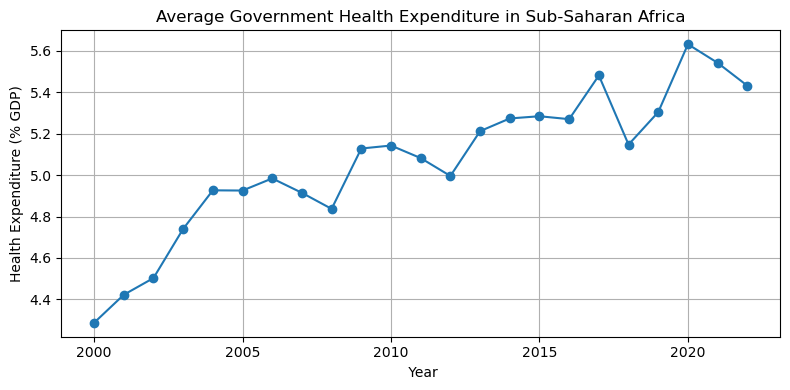

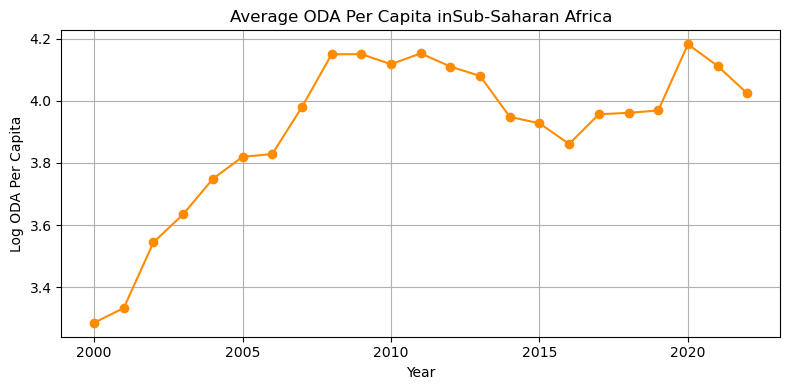

In [ ]:
#  regional aggregates by year
agg = panel.groupby("year").apply(
    lambda x: pd.Series({
        "health_exp_gdp": np.average(
            x["health_exp_gdp"].dropna()
        ),
        "log_oda_pc": np.average(
            x["log_oda_pc"].dropna()
        )
    })
).reset_index()

# Plot health expenditure over time
plt.figure(figsize=(8, 4))
plt.plot(agg["year"], agg["health_exp_gdp"], marker="o")
plt.xlabel(" Year")
plt.ylabel("Health Expenditure (% GDP)")
plt.title("Average Government Health Expenditure in Sub-Saharan Africa")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot ODA per capita over time
plt.figure(figsize=(8, 4))
plt.plot(agg["year"], agg["log_oda_pc"], marker="o", color="darkorange")
plt.xlabel("Year")
plt.ylabel("Log ODA Per Capita")
plt.title("Average ODA Per Capita in Sub-Saharan Africa")
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Stationarity and Autocorrelation

 Augmented Dickey-Fuller (ADF) test and  autocorrelation structure is tested via ACF and PACF plots. Non-stationary series require first-differencing to avoid misleading regression.

 cross-correlation function (CCF) between ODA and health expenditure is also examined to identify which lags carry the strongest predictive signal 

In [ ]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\nADF Test: {name}")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value:       {result[1]:.4f}")
    if result[1] < 0.05:
        print("  Conclusion: likely stationary")
    else:
        print("  Conclusion: likely non-stationary : consider differencing")

adf_test(agg["health_exp_gdp"], "Health Expenditure (% GDP)")
adf_test(agg["log_oda_pc"], "Log ODA Per Capita")


ADF Test: Health Expenditure (% GDP)
  ADF Statistic: -0.1507
  p-value:       0.9442
  Conclusion: likely non-stationary — consider differencing

ADF Test: Log ODA Per Capita
  ADF Statistic: -8.3390
  p-value:       0.0000
  Conclusion: likely stationary


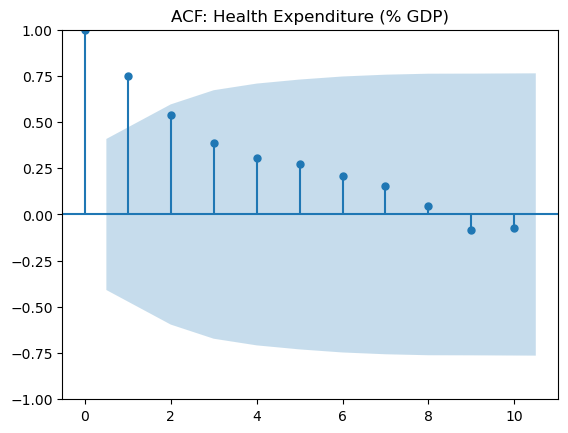

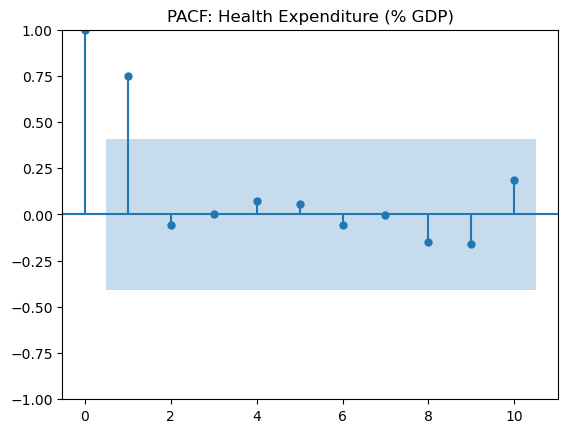

In [7]:
# ACF and PACF for health expenditure
plot_acf(agg["health_exp_gdp"].dropna(), lags=10)
plt.title("ACF: Health Expenditure (% GDP)")
plt.show()

plot_pacf(agg["health_exp_gdp"].dropna(), lags=10, method="ywm")
plt.title("PACF: Health Expenditure (% GDP)")
plt.show()

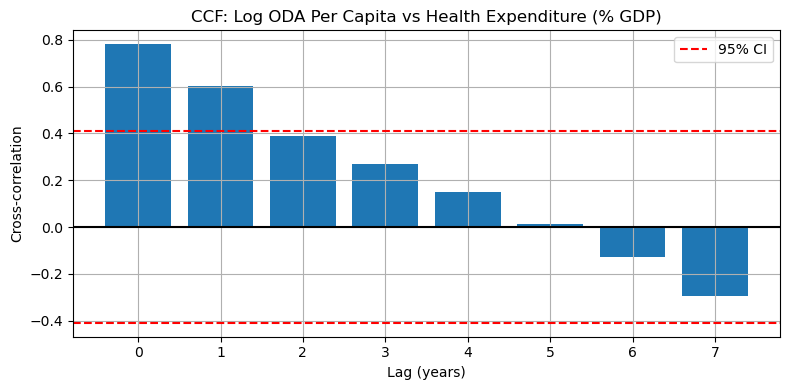

,lag,ccf
0,0,0.781
1,1,0.602
2,2,0.388
3,3,0.270
4,4,0.148
5,5,0.014
6,6,-0.128
7,7,-0.294


In [8]:
# Cross-correlation: ODA vs health expenditure
# Identifies which lags of ODA most strongly predict health expenditure

ccf_data = agg[["year", "log_oda_pc", "health_exp_gdp"]].dropna().copy()

x = ccf_data["log_oda_pc"] - ccf_data["log_oda_pc"].mean()
y = ccf_data["health_exp_gdp"] - ccf_data["health_exp_gdp"].mean()

n = len(x)
ci = 1.96 / np.sqrt(n)  # 95% confidence band

ccf_vals = ccf(x, y)
lags = np.arange(len(ccf_vals))

plt.figure(figsize=(8, 4))
plt.bar(lags[:8], ccf_vals[:8])
plt.axhline(ci, color="red", linestyle="--", label="95% CI")
plt.axhline(-ci, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.xlabel("Lag (years)")
plt.ylabel("Cross-correlation")
plt.title("CCF: Log ODA Per Capita vs Health Expenditure (% GDP)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

pd.DataFrame({"lag": lags[:8], "ccf": ccf_vals[:8].round(3)})

## 4. Panel Regression Model

The primary  model regresses government health expenditure (percent GDP) on lagged ODA per capita at lags 1, 2, and 3 years, interacted with the governance score. Country and year fixed effects are included:
- **Country fixed effects** absorbs stable between-country differences in baseline health spending, income, and health system capacity to account for the differences.
- **Year fixed effects** absorb global shocks (e.g., the 2008 financial crisis, COVID-19) that affect all countries simultaneously
- **Clustered standard errors** at the country level account for within-country serial correlation in residuals (this takes care of the heteroskedasticity)

The interaction terms (`log_oda_pc_lagN:governance`) test whether the ODA–health spending relationship is stronger in better-governed countries. A negative interaction coefficient would indicate that aid is less effective at increasing health spending in low-governance environments.

In [10]:
# Create lagged ODA variables within each country
for lag in [1, 2, 3]:
    panel[f"log_oda_pc_lag{lag}"] = (
        panel.groupby("country_code")["log_oda_pc"].shift(lag)
    )

# Drop rows missing key variables
model_data = panel.dropna(subset=[
    "health_exp_gdp",
    "governance",
    "log_oda_pc_lag1",
    "log_oda_pc_lag2",
    "log_oda_pc_lag3"
]).copy()

print(f"Modeling dataset: {model_data.shape[0]} country-year observations")

Modeling dataset: 722 country-year observations


In [12]:
# Main interaction model
model = smf.ols(
    formula="""
    health_exp_gdp ~
    log_oda_pc_lag1 * governance +
    log_oda_pc_lag2 * governance +
    log_oda_pc_lag3 * governance +
    C(country_code) +
    C(year)
    """,
    data=model_data
).fit(
    cov_type="cluster",
    cov_kwds={"groups": model_data["country_code"]}
)

# Display key coefficients only (excluding fixed effects)
key_terms = [
    "log_oda_pc_lag1",
    "log_oda_pc_lag2",
    "log_oda_pc_lag3",
    "governance",
    "log_oda_pc_lag1:governance",
    "log_oda_pc_lag2:governance",
    "log_oda_pc_lag3:governance"
]

model.summary2().tables[1].loc[key_terms, ["Coef.", "Std.Err.", "P>|z|", "[0.025", "0.975]"]]

/opt/anaconda3/envs/stats/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 63, but rank is 26
  warnings.warn('covariance of constraints does not have full '


,Coef.,Std.Err.,P>|z|,[0.025,0.975]
log_oda_pc_lag1,0.346255,0.125207,0.005684,0.100854,0.591656
log_oda_pc_lag2,0.053201,0.087239,0.541971,-0.117784,0.224187
log_oda_pc_lag3,0.098423,0.120008,0.412139,-0.136788,0.333633
governance,-0.701897,0.985460,0.476308,-2.633364,1.229570
log_oda_pc_lag1:governance,0.132349,0.103536,0.201146,-0.070577,0.335275
log_oda_pc_lag2:governance,-0.071046,0.093519,0.447434,-0.254340,0.112247
log_oda_pc_lag3:governance,-0.046892,0.114344,0.681736,-0.271003,0.177219


## 5. Model Diagnostics

Here, I check for model assumptions: residuals should be approximately normally distributed and show no strong autocorrelation or trend over time.

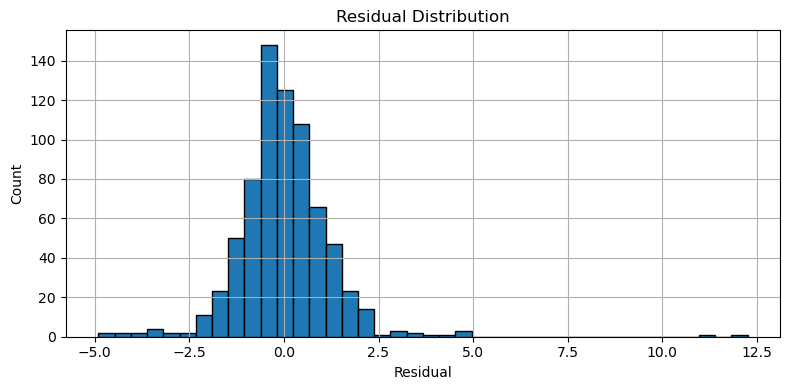

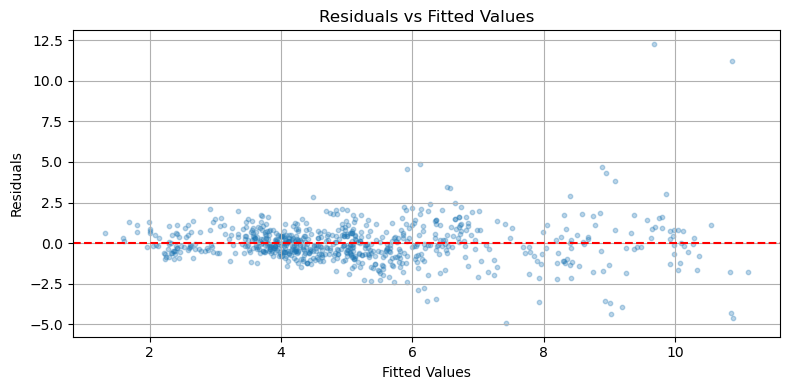

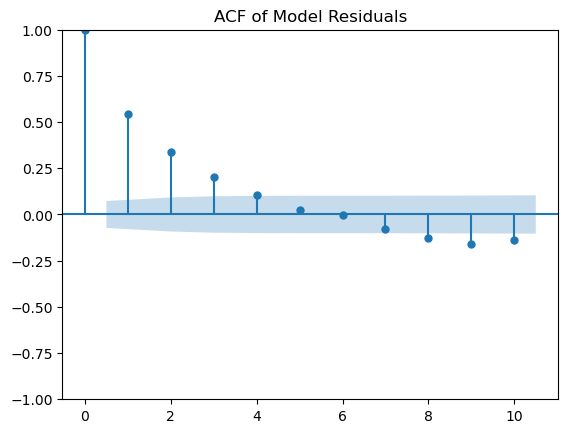

In [13]:
residuals = model.resid

# Residual distribution
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=40, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals vs fitted values
plt.figure(figsize=(8, 4))
plt.scatter(model.fittedvalues, residuals, alpha=0.3, s=10)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.grid(True)
plt.tight_layout()
plt.show()

# ACF of residuals — checks for remaining serial correlation
plot_acf(residuals, lags=10)
plt.title("ACF of Model Residuals")
plt.show()

## 6. Coefficient Plot

The coefficient plot below summarizes the key estimates from the model with 95% confidence intervals. Bars crossing zero indicate coefficients not statistically significant and are not distinguishable from no effect.

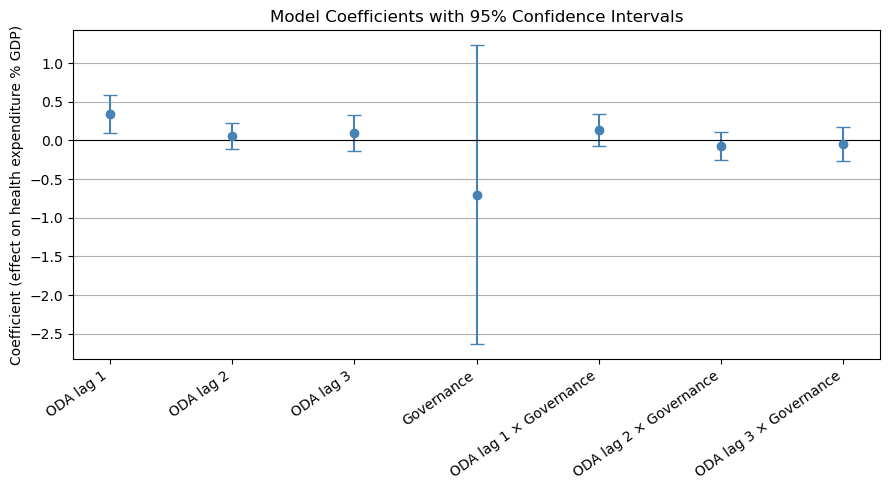

In [14]:
coef_table = model.summary2().tables[1]
coef_plot = coef_table.loc[key_terms]

labels = [
    "ODA lag 1",
    "ODA lag 2",
    "ODA lag 3",
    "Governance",
    "ODA lag 1 × Governance",
    "ODA lag 2 × Governance",
    "ODA lag 3 × Governance"
]

plt.figure(figsize=(9, 5))
plt.errorbar(
    x=range(len(key_terms)),
    y=coef_plot["Coef."],
    yerr=1.96 * coef_plot["Std.Err."],
    fmt="o",
    capsize=5,
    color="steelblue"
)
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(range(len(key_terms)), labels, rotation=35, ha="right")
plt.ylabel("Coefficient (effect on health expenditure % GDP)")
plt.title("Model Coefficients with 95% Confidence Intervals")
plt.tight_layout()
plt.grid(True, axis="y")
plt.show()

## 7. Conclusion
Overall, the results suggest that higher ODA per capita was associated with higher health expenditure one year later, even after controlling for country and year fixed effects. 
However, the relationship weakened and became statistically insignificant at longer lags, suggesting that the association between aid and health spending may be relatively short-term rather than persistent over multiple years. 

The governance interaction terms were also not statistically significant, meaning the analysis did not find strong evidence that governance quality systematically changed the relationship between aid and health expenditure. While the model captured the main relationship reasonably well, residual autocorrelation remained, indicating that some temporal structure in health expenditure was not fully explained by the regression model. 

The findings suggest that foreign aid may be associated with short-run increases in health spending, but the relationship appears more complex over longer time horizons and may depend on additional economic and institutional factors not fully captured in this analysis.